# Window-level AMPness along parent sequences

Join **`model_comparison_*.csv`** (per-window predictions) with **`window_map.csv`** from the sliding-window step (`peptide_id` ↔ `SEQ_<n>`).

- **Layout**: one **row per parent** (`parent_id`), one **column per model** (each `*_prob_AMP` column, or filtered by `PROB_COLUMN_SUBSTR`).
- **Scatter**: each window is one point; **x** = center index in the parent (`start + length/2`; `start` is 0-based from `window_map`).
- **Line**: for each residue index, the maximum P(AMP) among windows covering that residue (same as before, per panel).

If `window_map.csv` is missing, either re-run the pipeline windowing step or run the next cell (`SYNTH_IF_MISSING`) to regenerate a map from the homologue text file using the same window parameters as your run (default 20–35 aa, stride 1).

In [24]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "sequence_to_svm_minimal").is_dir():
            return p
    return here


ROOT = repo_root_from_here()

# --- edit these paths if needed ---
COMPARISON_CSV = ROOT / "sequence_to_svm_minimal/data/test/H2A_homologues_windowed/generated/model_comparison_latest.csv"
WINDOW_MAP_CSV = ROOT / "sequence_to_svm_minimal/data/test/H2A_homologues_windowed/generated/inputs/window_map.csv"

# Models to plot (columns ending with _prob_AMP). None = every model.
PROB_COLUMN_SUBSTR: str | None = None  # e.g. "Geo" to restrict; None = all

MAX_PARENTS = 12  # max parent rows; None = all parents
FIGWIDTH_PER_MODEL = 2.75  # subplot width per model column
FIGHEIGHT_PER_PARENT = 2.0  # subplot height per parent row

PLOT_MAIN_TITLE = "Predicted Antimicrobial Probability Across Parent Sequences"
PLOT_SUBTITLE = (
    "Dots: Window-level P(AMP) at center. Line: Maximum P(AMP) covering each residue."
)

print("ROOT:", ROOT)
print("comparison:", COMPARISON_CSV)
print("window_map:", WINDOW_MAP_CSV)

ROOT: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction
comparison: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\H2A_homologues_windowed\generated\model_comparison_latest.csv
window_map: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\H2A_homologues_windowed\generated\inputs\window_map.csv


In [25]:
import csv
import sys

# If the pipeline has not written `window_map.csv` yet, rebuild it from the same
# parent sequences + windowing parameters so `peptide_id` (SEQ_<n>) matches `canonical_seqs.txt`.
SYNTH_IF_MISSING = True
PARENTS_TXT = ROOT / "sequence_to_svm_minimal/data/test/H2A_homologues_windowed/H2AHomologues_Kyle.txt"
WINDOW_MIN_LEN, WINDOW_MAX_LEN, WINDOW_STRIDE = 20, 35, 1
WINDOW_MAP_FALLBACK = (
    ROOT
    / "sequence_to_svm_minimal/data/test/H2A_homologues_windowed/generated/inputs/window_map_notebook.csv"
)


def _parse_parent_records(path: Path) -> list[tuple[str, str]]:
    rows: list[tuple[str, str]] = []
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split(None, 1)
        if len(parts) == 2:
            rows.append((parts[0], parts[1].replace(" ", "")))
    return rows


if SYNTH_IF_MISSING and not WINDOW_MAP_CSV.is_file():
    sys.path.insert(0, str(ROOT / "sequence_to_svm_minimal"))
    from peptide_pipeline.windowing import expand_records_to_windows

    recs = _parse_parent_records(PARENTS_TXT)
    _, windows = expand_records_to_windows(
        recs,
        min_len=WINDOW_MIN_LEN,
        max_len=WINDOW_MAX_LEN,
        stride=WINDOW_STRIDE,
    )
    WINDOW_MAP_FALLBACK.parent.mkdir(parents=True, exist_ok=True)
    with open(WINDOW_MAP_FALLBACK, "w", newline="", encoding="utf-8") as wf:
        writer = csv.DictWriter(
            wf,
            fieldnames=[
                "seqIndex",
                "peptide_id",
                "window_id",
                "parent_id",
                "start",
                "length",
                "sequence",
            ],
        )
        writer.writeheader()
        for w in windows:
            writer.writerow(
                {
                    "seqIndex": w.seq_index,
                    "peptide_id": w.peptide_id,
                    "window_id": w.window_id,
                    "parent_id": w.parent_id,
                    "start": w.start,
                    "length": w.length,
                    "sequence": w.window_seq,
                }
            )
    WINDOW_MAP_CSV = WINDOW_MAP_FALLBACK
    print("Wrote synthetic window_map:", WINDOW_MAP_CSV, "| windows:", len(windows))
elif not WINDOW_MAP_CSV.is_file():
    print("window_map missing; set SYNTH_IF_MISSING = True or add window_map.csv")
else:
    print("Using window_map:", WINDOW_MAP_CSV)

Using window_map: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\test\H2A_homologues_windowed\generated\inputs\window_map.csv


In [26]:
SUFFIX = "_prob_AMP"


def pick_prob_columns(cols: list[str], substr: str | None) -> list[str]:
    out = sorted(c for c in cols if c.endswith(SUFFIX))
    if substr:
        out = [c for c in out if substr in c]
    return out


def load_merged(comparison_csv: Path, window_map_csv: Path) -> pd.DataFrame:
    if not window_map_csv.is_file():
        raise FileNotFoundError(
            f"window_map not found: {window_map_csv}\n"
            "Generate it via the peptide pipeline windowing step (writes window_map.csv next to canonical_seqs)."
        )
    comp = pd.read_csv(comparison_csv)
    wmap = pd.read_csv(window_map_csv)
    need = {"peptide_id", "parent_id", "start", "length"}
    miss = need - set(wmap.columns)
    if miss:
        raise ValueError(f"window_map.csv missing columns: {sorted(miss)}")
    w_sub = wmap[["peptide_id", "parent_id", "start", "length", "window_id"]].copy()
    df = comp.merge(w_sub, on="peptide_id", how="inner")
    if df.empty:
        raise ValueError("Merge produced 0 rows: check peptide_id matches between comparison CSV and window_map.")
    df["center"] = df["start"].astype(float) + df["length"].astype(float) / 2.0
    return df


def max_prob_along_parent(parent_df: pd.DataFrame, prob_col: str, parent_len: int) -> np.ndarray:
    pos = np.zeros(parent_len, dtype=np.float64)
    for _, r in parent_df.iterrows():
        s = int(r["start"])
        L = int(r["length"])
        v = float(r[prob_col])
        if not math.isfinite(v):
            continue
        lo, hi = max(0, s), min(parent_len, s + L)
        if lo < hi:
            pos[lo:hi] = np.maximum(pos[lo:hi], v)
    return pos


def plot_ampness_panels(
    df: pd.DataFrame,
    prob_cols: list[str],
    *,
    max_parents: int | None = 12,
    figwidth_per_model: float = 2.75,
    figheight_per_parent: float = 2.0,
    main_title: str = "Window-level P(AMP) along parent sequences",
    subtitle: str = "",
) -> None:
    """One row per parent, one column per model: same scatter + max-envelope in each panel."""
    parents = sorted(df["parent_id"].astype(str).unique())
    if max_parents is not None:
        parents = parents[:max_parents]
    if not parents:
        print("No parent_id values to plot.")
        return
    if not prob_cols:
        print("No probability columns to plot.")
        return

    # Left-to-right: reverse default sorted model order (e.g. Combined … ESM-only).
    prob_cols = list(reversed(prob_cols))

    n_p, n_m = len(parents), len(prob_cols)
    fig_w = figwidth_per_model * n_m
    fig_h = figheight_per_parent * n_p
    fig, axes = plt.subplots(
        n_p,
        n_m,
        figsize=(fig_w, fig_h),
        sharex="col",
        sharey="row",
        squeeze=False,
    )
    axes = np.atleast_2d(np.asarray(axes, dtype=object))

    for i, pid in enumerate(parents):
        sub = df[df["parent_id"].astype(str) == pid].sort_values(["start", "length"])
        parent_len = int((sub["start"] + sub["length"]).max())
        x_idx = np.arange(parent_len)

        for j, pc in enumerate(prob_cols):
            ax = axes[i, j]
            label = pc[: -len(SUFFIX)]
            color = f"C{j}"
            ax.scatter(sub["center"], sub[pc], s=6, alpha=0.35, color=color)
            env = max_prob_along_parent(sub, pc, parent_len)
            ax.plot(x_idx, env, linewidth=1.4, alpha=0.95, color=color)
            ax.set_ylim(-0.02, 1.02)
            ax.grid(True, alpha=0.25)
            if i == 0:
                ax.set_title(label, fontsize=10, fontweight="bold")
            if j == 0:
                ax.set_ylabel("P(AMP)", fontsize=9)
            if j == n_m - 1:
                ax2 = ax.twinx()
                ax2.set_ylabel(pid, rotation=270, labelpad=15, fontsize=10, fontweight="bold")
                ax2.set_yticks([])
            if i == n_p - 1:
                ax.set_xlabel("Residue index (0-based)", fontsize=9)

    fig.suptitle(main_title, fontsize=14, fontweight="bold", y=0.98)
    if subtitle:
        fig.text(
            0.5,
            0.94,
            subtitle,
            ha="center",
            fontsize=10,
            color="0.25",
            transform=fig.transFigure,
        )
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

merged rows: 8264 | parents: 5
plotting: ['ESM+Combined32_prob_AMP', 'ESM+Geo20_prob_AMP', 'ESM+QSAR12_prob_AMP', 'ESM-only_prob_AMP']


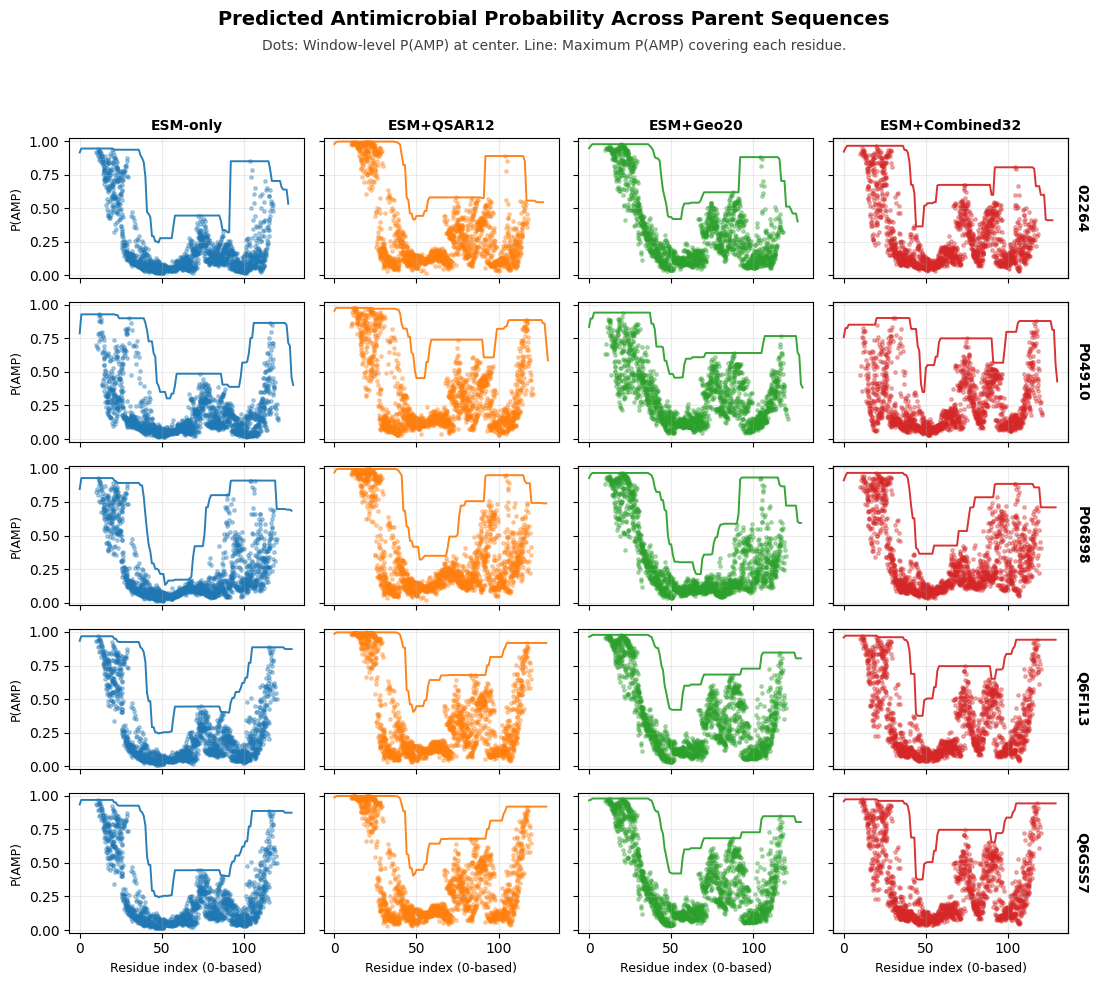

In [27]:
df = load_merged(COMPARISON_CSV, WINDOW_MAP_CSV)
prob_cols = pick_prob_columns(list(df.columns), PROB_COLUMN_SUBSTR)
if not prob_cols:
    raise ValueError(f"No prob columns matching suffix {SUFFIX!r} and substr={PROB_COLUMN_SUBSTR!r}")

print("merged rows:", len(df), "| parents:", df["parent_id"].nunique())
print("plotting:", prob_cols)

plot_ampness_panels(
    df,
    prob_cols,
    max_parents=MAX_PARENTS,
    figwidth_per_model=FIGWIDTH_PER_MODEL,
    figheight_per_parent=FIGHEIGHT_PER_PARENT,
    main_title=PLOT_MAIN_TITLE,
    subtitle=PLOT_SUBTITLE,
)